# **IMPORTING LIBRARY**

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

In [72]:
df = pd.read_csv('/content/price_history.csv')

In [73]:
df.head()

,id,node_id,fuel_type,price_pence,recorded_at,source_updated_at
0,1,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,E10,126.0,2026-02-07T21:40:01.511Z,2026-02-06T12:46:05.000Z
1,2,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,B7_STANDARD,135.0,2026-02-07T21:40:01.511Z,2026-02-06T12:46:05.000Z
2,3,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,E10,127.0,2026-02-07T21:40:01.511Z,2026-02-01T11:04:45.000Z
3,4,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,B7_STANDARD,138.0,2026-02-07T21:40:01.511Z,2026-02-01T11:04:45.000Z
4,5,ae5b2f8f6979b8b2460ff52f85619dd0dfc6a10bc98ca1...,E5,146.0,2026-02-07T21:40:01.511Z,2026-02-06T13:57:50.000Z


# **Exploratory Data Analysis**

In [74]:
df.shape

(337342, 6)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337342 entries, 0 to 337341
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 337342 non-null  int64  
 1   node_id            337342 non-null  object 
 2   fuel_type          337342 non-null  object 
 3   price_pence        337342 non-null  float64
 4   recorded_at        337342 non-null  object 
 5   source_updated_at  337342 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 15.4+ MB


In [76]:
df.describe()

,id,price_pence
count,337342.000000,337342.000000
mean,169073.354705,159.712960
std,97731.543558,36.896679
min,1.000000,0.000000
25%,84336.250000,143.900000
50%,168853.500000,155.900000
75%,253907.750000,171.900000
max,338243.000000,1990.000000


In [77]:
df.isnull().sum()

,0
id,0
node_id,0
fuel_type,0
price_pence,0
recorded_at,0
source_updated_at,0


In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df_price0 = df.loc[df['price_pence'] == 0.0] # Mengecek jumlah row dengan column harga = 0.0
print(df_price0.shape[0])

2


In [80]:
df_price_Max = df.loc[df['price_pence'] == 1990.0]  # Mengecek jumlah row dengan column harga = 1990.0
print(df_price_Max.shape[0])

1


In [81]:
df_10_highest = df.sort_values(by='price_pence', ascending=False).head(10) # Mengecek 10 harga minyak tertinggi
df_10_highest

,id,node_id,fuel_type,price_pence,recorded_at,source_updated_at
307630,308532,4cd7c86575c308d2a77e616cad61ab61dace0e84ea53cb...,B7_PREMIUM,1990.0,2026-03-31T11:08:02.773Z,2026-03-31T11:07:09.000Z
130059,130242,7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...,B7_PREMIUM,1949.0,2026-03-09T12:48:07.713Z,2026-03-09T12:46:49.608Z
327378,328280,80bda2adce6afa12be9f8897367e3faba33ed5be5e430f...,E5,1889.0,2026-04-02T08:36:14.345Z,2026-04-02T08:35:39.000Z
271032,271934,2fad70a7020430ee35e4c299a793de527ab77e41735e6d...,B7_STANDARD,1819.0,2026-03-26T15:28:02.609Z,2026-03-26T15:25:14.000Z
212282,212827,0c5dee22ecf242d1027b6118eac744e01755e080df95a1...,B7_STANDARD,1777.0,2026-03-20T18:12:06.829Z,2026-03-20T18:09:07.000Z
169547,169730,3631dbafa225c68604b9d288cf0b44e26a14912ce713d8...,B7_STANDARD,1749.0,2026-03-16T07:16:01.225Z,2026-03-16T07:15:05.000Z
210995,211540,91909366652067d23e82c14e9d55924d3ddf1549434440...,B7_STANDARD,1749.0,2026-03-20T16:32:23.705Z,2026-03-20T16:28:16.000Z
130056,130239,7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...,E5,1709.0,2026-03-09T12:48:07.713Z,2026-03-09T12:46:49.608Z
130058,130241,7e54b71d4fc9e3cd9d0f87e6ff69184eb7001a3de05c08...,B7_STANDARD,1699.0,2026-03-09T12:48:07.713Z,2026-03-09T12:46:49.608Z
3311,3312,24c76ae2c22792c298a81faeccbf2874cf2e9549135fcf...,E5,1699.0,2026-02-07T21:40:01.860Z,2026-02-02T10:29:16.000Z


In [82]:
df = df.drop(df_price0.index) # Menghapus row dengan column harga = 0.0

Check the distribution of oil prices

<function matplotlib.pyplot.show(close=None, block=None)>

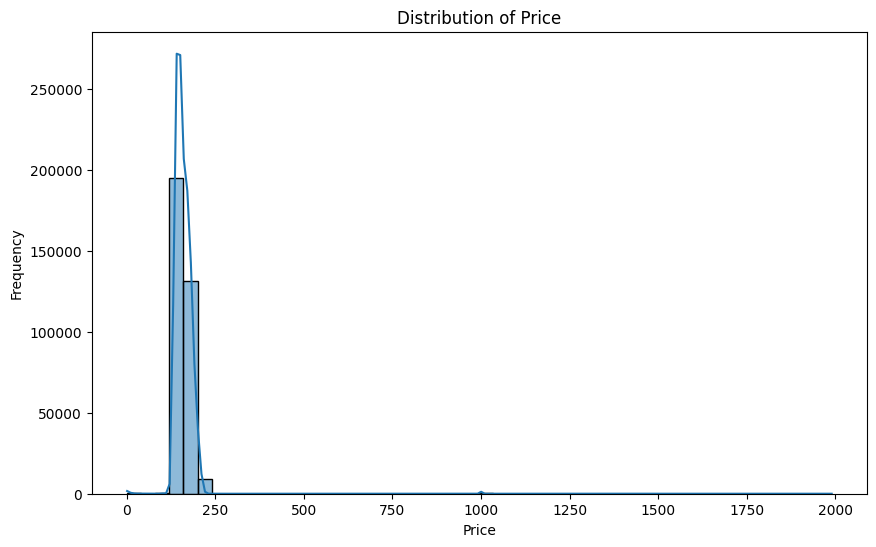

In [83]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_pence'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show

Dari histogram di atas, saya mendapatkan insight:

1.   **Mayoritas harga** terkonsentrasi di rentang **100–250 pence**, dengan puncak tertinggi di sekitar **150–175 pence**
2.   Distribusi ini berisfat **right-skewed** atau ekor memanjang ke kanan yang berarti terdapat ouliers di sana



<function matplotlib.pyplot.show(close=None, block=None)>

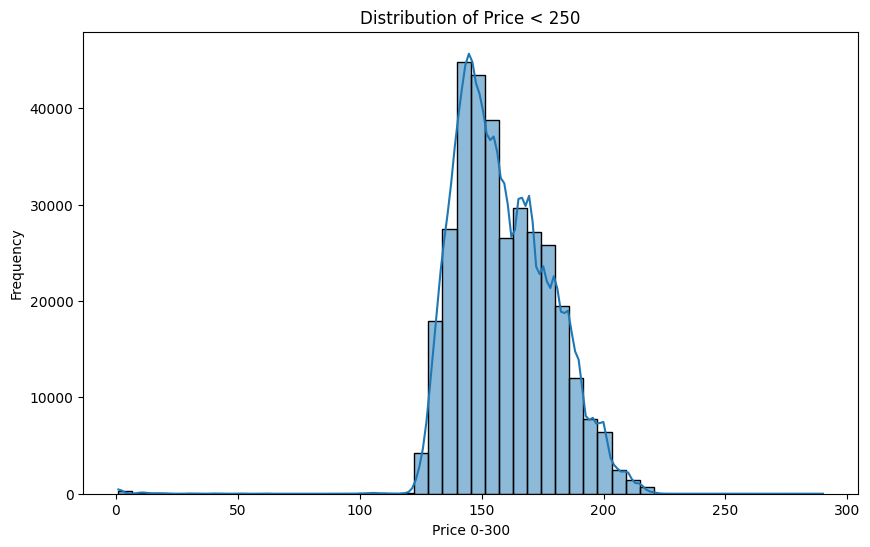

In [84]:
df_under_300 = df.loc[df['price_pence'] < 300] #Memfilter dataframe menjadi < 300 karena banyak outliers.
plt.figure(figsize=(10, 6))
sns.histplot(df_under_300['price_pence'], bins=50, kde=True) #mengubah bins agar lebih detail
plt.title('Distribution of Price < 250')
plt.xlabel('Price 0-300')
plt.ylabel('Frequency')
plt.show

Setelah dilakukan filtering dan melihat lebih detail distribusinya dengan menambahkan parameter bins-nya, bisa dilihat bahwa:

1.   **Puncak utama** berada di sekitar **140–150 pence**
2.   Distribusi jauh lebih mendekati normal dibanding histogram data asli
3. Terdapat **dua puncak kecil (bimodal)** di sekitar 175–200 pence
  di samping puncak utama



In [85]:
df_sus = df[df['price_pence'] > 500] #Mengecek seberapa pengaruh data outlier ini
print(df_sus.shape[0])
print(f"{df_sus.shape[0]/df.shape[0]*100:.2f}%") # Ternyata perbandingan dari jumlah asli dan jumlah di atas 500 hanya 0.10, maka dilakukanlah penghapusan data di atas 500

336
0.10%


In [86]:
df_ori = df.copy()

In [87]:
df = df[df['price_pence'] <= 500.0] #Menghapus dataset yang data 'price_pence' > 500.0

In [88]:
print(df.shape)

(337004, 6)


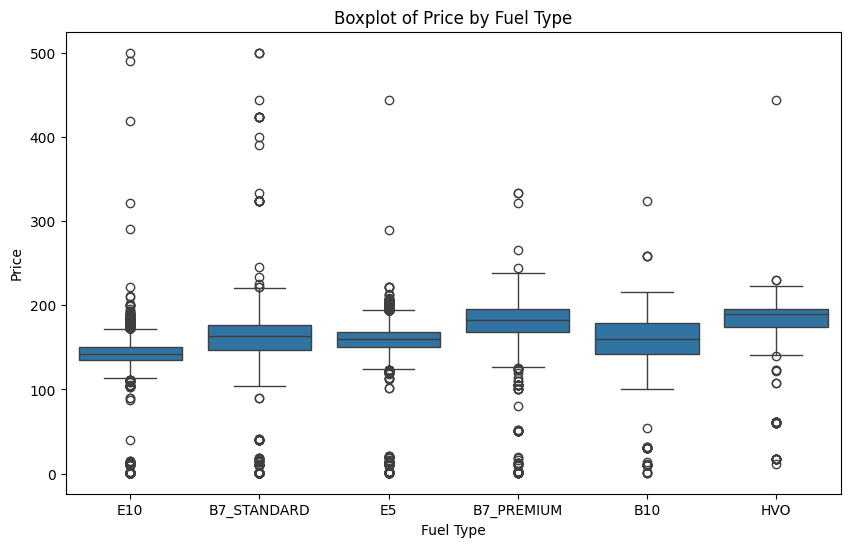

In [89]:
plt.figure(figsize=(10, 6)) #Melihat perbandingan harga antar type fuel-nya.
sns.boxplot(data=df, x='fuel_type', y='price_pence')
plt.title('Boxplot of Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

Dari boxplot ini, saya bisa menyimpulkan bahwa:

1.   **Fuel type E10** adalah bahan bakar termurah di UK dengan Q2 nya menyentuh di kisaran **145.0**
2.   **Semua jenis bahan bakar** masih memiliki outlier **di atas 300** dan **di bawah 50**



In [90]:
df_und_100 = df[df['price_pence'] < 100] #Mencoba untuk memfilter dataset dengan melihat jumlah data yang 'price_pence' nya < 100 pence
print(df_und_100.shape[0])
print(f"{df_und_100.shape[0]/df.shape[0]*100:.2f}%")

539
0.16%


In [91]:
df_ori2 = df.copy()
df = df[df['price_pence'] >= 100] #Menghapus price_pence yang < 100 pence

In [92]:
df.shape[0]

336465

In [93]:
df['recorded_at'] = pd.to_datetime(df['recorded_at']) #Mengubah type data 'recorded_at' menjadi datetime
print(df['recorded_at'].min()) #Mengecek tanggal pertama dan tanggal terakhir dalam dataset ini
print(df['recorded_at'].max())
print(df['recorded_at'].dt.year.value_counts().sort_index())

2026-02-07 21:40:01.511000+00:00
2026-04-03 00:24:03.747000+00:00
recorded_at
2026    336465
Name: count, dtype: int64


In [94]:
tren_per_fuel = df.groupby([
    df['recorded_at'].dt.to_period('M'),
    'fuel_type'])['price_pence'].mean().reset_index()

print(tren_per_fuel) # Mengelompokkan per bulan dan per jenis bahan bakar untuk melihat tren harga masing-masing fuel type dari waktu ke waktu

   recorded_at    fuel_type  price_pence
0      2026-02          B10   148.786780
1      2026-02   B7_PREMIUM   161.947640
2      2026-02  B7_STANDARD   142.335849
3      2026-02          E10   132.971246
4      2026-02           E5   149.883022
5      2026-02          HVO   171.561414
6      2026-03          B10   169.809633
7      2026-03   B7_PREMIUM   184.720785
8      2026-03  B7_STANDARD   165.475306
9      2026-03          E10   144.418085
10     2026-03           E5   161.111856
11     2026-03          HVO   187.865753
12     2026-04          B10   196.494737
13     2026-04   B7_PREMIUM   205.567819
14     2026-04  B7_STANDARD   186.299910
15     2026-04          E10   154.850883
16     2026-04           E5   172.673708
17     2026-04          HVO   201.339216


/tmp/ipykernel_11739/1974883944.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['recorded_at'].dt.to_period('M'),


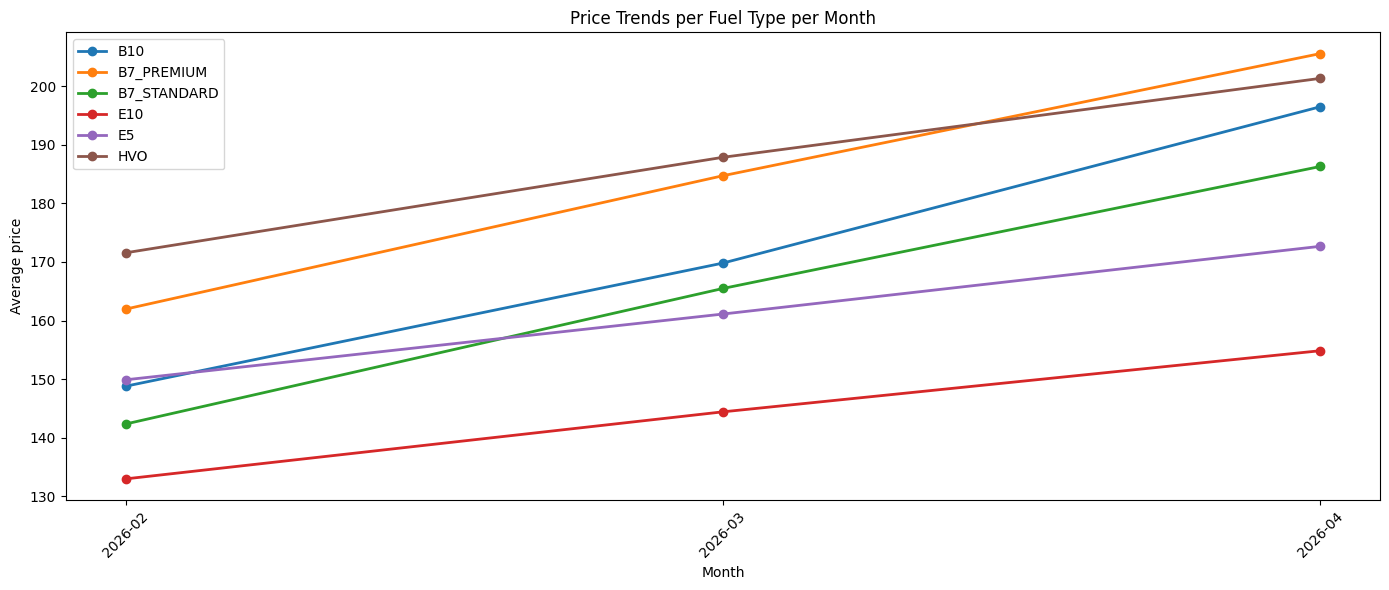

In [95]:
tren_per_fuel['recorded_at'] = tren_per_fuel['recorded_at'].astype(str) # Mengubah type data menjadi string agar library matplotlib bisa membaca sbg label sumbu X

plt.figure(figsize=(14, 6))
for fuel in tren_per_fuel['fuel_type'].unique(): # Mengambil daftar fuel_type yang tidak duplikat
    fuel_data = tren_per_fuel[tren_per_fuel['fuel_type'] == fuel]
    plt.plot(fuel_data['recorded_at'], fuel_data['price_pence'], marker='o', linewidth=2, label=fuel)

plt.title("Price Trends per Fuel Type per Month")
plt.xlabel('Month')
plt.ylabel('Average price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Dari line chart ini bisa dilihat bahwa:

1.   **Semua jenis bahan bakar menunjukkan tren naik yang konsisten**
2.   Kenaikannya **linear** yang artinya faktor eksternal sistemik seperti kebijakan harga atau
  kenaikan harga minyak dunia yang mempengaruhi semua jenis
  bahan bakar secara bersamaan

Dataset hanya mencakup **3 bulan (Feb–Apr 2026)** sehingga
  tidak cukup untuk mengidentifikasi pola musiman atau
  tren jangka panjang yang lebih bermakna



In [96]:
tren_harian = df.groupby(
    df['recorded_at'].dt.dayofweek)['price_pence'].mean().reset_index() #Mengabungkan rata-rata price_pence dengan hari-nya

tren_harian = tren_harian.rename(columns={'recorded_at': 'day_of_week'})

In [97]:
day_mapping = {
    0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4: 'Jumat', 5: 'Sabtu', 6: 'Minggu'
} #Membuat mapping hari agar visualnya lebih informatif

In [98]:
tren_harian['day_of_week'] = tren_harian['day_of_week'].map(day_mapping)
print(tren_harian)

  day_of_week  price_pence
0       Senin   160.740594
1      Selasa   159.406453
2        Rabu   161.844991
3       Kamis   162.228851
4       Jumat   160.214662
5       Sabtu   154.398063
6      Minggu   153.558401


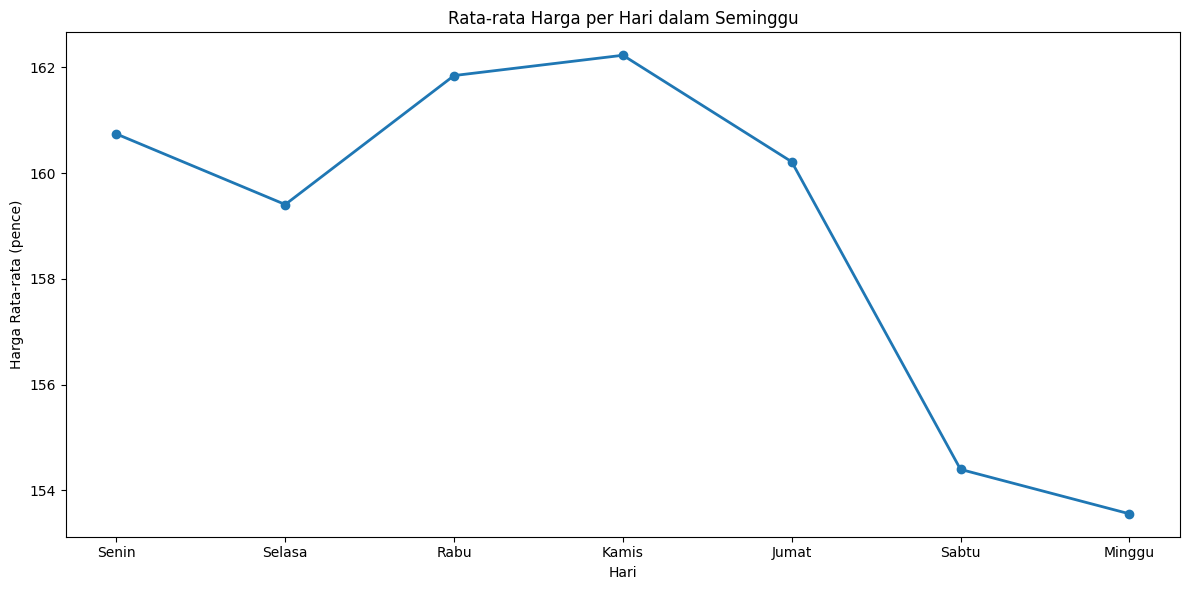

In [99]:
plt.figure(figsize=(12, 6))
plt.plot(tren_harian['day_of_week'], tren_harian['price_pence'],
         marker='o', linewidth=2)
plt.title('Rata-rata Harga per Hari dalam Seminggu')
plt.xlabel('Hari')
plt.ylabel('Harga Rata-rata (pence)')
plt.tight_layout()
plt.show()

Dari hasil line chart ini, saya bisa melihat bahwa:

1.   **Kamis adalah hari termahal** (~162.3 pence)
2.   Harga pada **hari kerja** secara konsisten pasti lebih tinggi dibanding **hari weekend**



# **Data Preprocessing**

**Feature Engineering**

In [100]:
df['day_of_week'] = df['recorded_at'].dt.dayofweek
df['month'] = df['recorded_at'].dt.month
start_date = df['recorded_at'].min()
df['days_since_start'] = (df['recorded_at'] - start_date).dt.days #Membuat fitur-fitur yang dibutuhkan

In [101]:
df.head()

,id,node_id,fuel_type,price_pence,recorded_at,source_updated_at,day_of_week,month,days_since_start
0,1,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,E10,126.0,2026-02-07 21:40:01.511000+00:00,2026-02-06T12:46:05.000Z,5,2,0
1,2,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,B7_STANDARD,135.0,2026-02-07 21:40:01.511000+00:00,2026-02-06T12:46:05.000Z,5,2,0
2,3,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,E10,127.0,2026-02-07 21:40:01.511000+00:00,2026-02-01T11:04:45.000Z,5,2,0
3,4,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,B7_STANDARD,138.0,2026-02-07 21:40:01.511000+00:00,2026-02-01T11:04:45.000Z,5,2,0
4,5,ae5b2f8f6979b8b2460ff52f85619dd0dfc6a10bc98ca1...,E5,146.0,2026-02-07 21:40:01.511000+00:00,2026-02-06T13:57:50.000Z,5,2,0


In [102]:
df.tail()

,id,node_id,fuel_type,price_pence,recorded_at,source_updated_at,day_of_week,month,days_since_start
337337,338239,784f1d06c3b587b30bb968f6ea6b35176df3b17414abe8...,B7_STANDARD,185.9,2026-04-03 00:05:39.075000+00:00,2026-04-02T22:05:35.000Z,4,4,54
337338,338240,620243f4f47323593c04c4acf0c4659d2e1d3dff090b43...,B7_STANDARD,191.9,2026-04-03 00:08:03.055000+00:00,2026-04-03T00:07:55.000Z,4,4,54
337339,338241,620243f4f47323593c04c4acf0c4659d2e1d3dff090b43...,B7_PREMIUM,201.9,2026-04-03 00:08:03.055000+00:00,2026-04-03T00:07:55.000Z,4,4,54
337340,338242,ed89755a8b4db89761891d3026d8d245e4f7f20b1222c1...,E10,156.9,2026-04-03 00:24:03.747000+00:00,2026-04-03T00:23:05.000Z,4,4,54
337341,338243,ed89755a8b4db89761891d3026d8d245e4f7f20b1222c1...,B7_STANDARD,187.9,2026-04-03 00:24:03.747000+00:00,2026-04-03T00:23:05.000Z,4,4,54


**One-Hot Encoding**

In [103]:
if 'fuel_type' in df.columns:
    df = pd.get_dummies(df, columns=['fuel_type'], prefix='fuel') #Mengubah kolom fuel_type menjadi boolean agar dikenali oleh model saat training
else:
  print("lol")
print(df.head())

   id                                            node_id  price_pence  \
0   1  4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...        126.0   
1   2  4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...        135.0   
2   3  b739362af81acc9fec9eda6f155348125fa2d5c1772c96...        127.0   
3   4  b739362af81acc9fec9eda6f155348125fa2d5c1772c96...        138.0   
4   5  ae5b2f8f6979b8b2460ff52f85619dd0dfc6a10bc98ca1...        146.0   

                       recorded_at         source_updated_at  day_of_week  \
0 2026-02-07 21:40:01.511000+00:00  2026-02-06T12:46:05.000Z            5   
1 2026-02-07 21:40:01.511000+00:00  2026-02-06T12:46:05.000Z            5   
2 2026-02-07 21:40:01.511000+00:00  2026-02-01T11:04:45.000Z            5   
3 2026-02-07 21:40:01.511000+00:00  2026-02-01T11:04:45.000Z            5   
4 2026-02-07 21:40:01.511000+00:00  2026-02-06T13:57:50.000Z            5   

   month  days_since_start  fuel_B10  fuel_B7_PREMIUM  fuel_B7_STANDARD  \
0      2               

In [104]:
df.head()

,id,node_id,price_pence,recorded_at,source_updated_at,day_of_week,month,days_since_start,fuel_B10,fuel_B7_PREMIUM,fuel_B7_STANDARD,fuel_E10,fuel_E5,fuel_HVO
0,1,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,126.0,2026-02-07 21:40:01.511000+00:00,2026-02-06T12:46:05.000Z,5,2,0,False,False,False,True,False,False
1,2,4882e3fee979cfefa29a8777ce57ca0ecea27b4f12ba7f...,135.0,2026-02-07 21:40:01.511000+00:00,2026-02-06T12:46:05.000Z,5,2,0,False,False,True,False,False,False
2,3,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,127.0,2026-02-07 21:40:01.511000+00:00,2026-02-01T11:04:45.000Z,5,2,0,False,False,False,True,False,False
3,4,b739362af81acc9fec9eda6f155348125fa2d5c1772c96...,138.0,2026-02-07 21:40:01.511000+00:00,2026-02-01T11:04:45.000Z,5,2,0,False,False,True,False,False,False
4,5,ae5b2f8f6979b8b2460ff52f85619dd0dfc6a10bc98ca1...,146.0,2026-02-07 21:40:01.511000+00:00,2026-02-06T13:57:50.000Z,5,2,0,False,False,False,False,True,False


**Splitting**

In [105]:
df = df.sort_values('recorded_at').reset_index(drop=True)

In [106]:
feature_col = ['day_of_week', 'days_since_start',
              'fuel_E10', 'fuel_B7_STANDARD', 'fuel_E5',
              'fuel_B7_PREMIUM', 'fuel_B10', 'fuel_HVO']

target_col = 'price_pence'

In [107]:
date_limit = '2026-03-31'
train = df[df['recorded_at'] <= date_limit]
test = df[df['recorded_at'] > date_limit]

In [108]:
X_train = train[feature_col]
y_train = train[target_col]

X_test = test[feature_col]
y_test = test[target_col]

nan_indices_train = y_train.isnull()
X_train = X_train[~nan_indices_train]
y_train = y_train[~nan_indices_train]

nan_indices_test = y_test.isnull()
X_test = X_test[~nan_indices_test]
y_test = y_test[~nan_indices_test]

In [109]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(304850, 8)
(304850,)
(31615, 8)
(31615,)


In [110]:
columns_to_drop = ['recorded_at', 'node_id', 'id', 'source_updated_at']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print("sukses")
else:
    print("error kocak")

sukses


In [111]:
df.head()

,price_pence,day_of_week,month,days_since_start,fuel_B10,fuel_B7_PREMIUM,fuel_B7_STANDARD,fuel_E10,fuel_E5,fuel_HVO
0,126.0,5,2,0,False,False,False,True,False,False
1,130.0,5,2,0,False,False,False,True,False,False
2,140.0,5,2,0,False,False,True,False,False,False
3,161.0,5,2,0,False,True,False,False,False,False
4,141.0,5,2,0,False,False,False,False,True,False


# **Model Training**

**Hyperparameter Tuning**

In [112]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

**Ensemble Learning**

In [118]:
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=2)

In [119]:
joblib.dump(random_search, 'random_forest_fuel_prices.pkl')

['random_forest_fuel_prices.pkl']

**Final Result**

In [120]:
print(random_search.best_params_)
print(f"\nBest CV Score: {random_search.best_score_:.4f}")

{'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 10}

Best CV Score: 0.4736


In [121]:
best_rfr = random_search.best_estimator_
y_pred_best = best_rfr.predict(X_test)

In [122]:
mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

print(f"MAE  : {mae_best:.2f} pence")
print(f"RMSE : {rmse_best:.2f} pence")
print(f"R²   : {r2_best:.4f}")

MAE  : 7.51 pence
RMSE : 10.19 pence
R²   : 0.6813


## **Final Result & Business Insights**

1.   Keberhasilan Model dalam Menangkap Tren

Model Ensemble **(Random Forest)** berhasil mengidentifikasi bahwa Waktu (days_since_start) dan Jenis Bahan Bakar (fuel_type) adalah faktor penentu utama harga. Dengan skor **$R^2$** sebesar **0.68**, model ini mampu menjelaskan mayoritas variasi harga bensin di pasar UK untuk periode Februari - April 2026.

2.   Limitasi Algoritma terhadap Ekstrapolasi

Insight paling krusial dari proyek ini adalah penemuan bahwa **model cenderung underestimate pada harga tinggi di bulan April**. Hal ini disebabkan oleh keterbatasan alami **algoritma berbasis pohon** (Tree-based models) yang tidak dapat memprediksi nilai di luar rentang data trainingnya. Meskipun telah dilakukan Hyperparameter Tuning, **MAE** tetap tertahan di angka **7.51 pence**, membuktikan bahwa kendala utama terletak pada karakteristik data (tren naik), bukan pada parameter model.

3. Karakteristik Segmentasi Pasar

Melalui EDA dan Feature Importance, ditemukan segmentasi yang jelas antara:

*   Kelompok Ekonomi (E10): Harga paling murah dan paling banyak digunakan.
*   Kelompok Premium (B7_PREMIUM & HVO): Memiliki harga jauh di atas rata-rata namun dengan variasi yang lebih stabil.
*   Weekend Effect: Terdapat pola penurunan harga di akhir pekan, namun pengaruhnya kalah dominan dibandingkan tren kenaikan harga nasional secara harian.






